# Clasificador de Piezas de Ajedrez — Iconos Online (85x85)
**Dataset:** s4lman/chess-pieces-dataset-85x85  
**Estructura:** `data/{bishop,king,knight,pawn,queen,rook}/`  
**Modelo:** MobileNetV2 fine-tuning (generaliza a vistas laterales y frontales)
**Alumno:** Arturo Pérez González 215510


In [1]:
!pip install -q kagglehub


## 1. Descarga del Dataset


In [2]:
import kagglehub
import os, numpy as np, matplotlib.pyplot as plt
from PIL import Image

path = kagglehub.dataset_download("s4lman/chess-pieces-dataset-85x85")
print("Path to dataset files:", path)

# Mostrar estructura completa con conteo de imagenes
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    if level > 4: continue
    n = sum(1 for f in files if f.lower().endswith((".png",".jpg",".jpeg",".webp")))
    indent = "  " * level
    label  = f" [{n} imgs]" if n > 0 else ""
    print(f"{indent}{os.path.basename(root)}/{label}")


100%|██████████| 5.95M/5.95M [00:02<00:00, 3.05MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/s4lman/chess-pieces-dataset-85x85/versions/2
2/
  data/
    rook/ [72 imgs]
    pawn/ [239 imgs]
    knight/ [71 imgs]
    king/ [34 imgs]
    queen/ [34 imgs]
    bishop/ [67 imgs]


## 2. Localizar Directorio de Clases


In [3]:
# Buscar el directorio cuyas subcarpetas contienen las imagenes
DATA_DIR    = None
best_score  = 0

for root, dirs, files in os.walk(path):
    class_dirs = [
        d for d in dirs
        if any(f.lower().endswith((".png",".jpg",".jpeg"))
               for f in os.listdir(os.path.join(root, d)))
    ]
    if len(class_dirs) > best_score:
        best_score = len(class_dirs)
        DATA_DIR   = root

classes = sorted([
    d for d in os.listdir(DATA_DIR)
    if os.path.isdir(os.path.join(DATA_DIR, d))
])
NUM_CLASSES = len(classes)

print(f"DATA_DIR: {DATA_DIR}")
print(f"Clases ({NUM_CLASSES}): {classes}")
for cls in classes:
    n = len([
        f for f in os.listdir(os.path.join(DATA_DIR, cls))
        if f.lower().endswith((".png",".jpg",".jpeg"))
    ])
    print(f"  {cls}: {n} imagenes")

# Verificar tamano nativo
sample_dir = os.path.join(DATA_DIR, classes[0])
sample_img = next(f for f in os.listdir(sample_dir)
                  if f.lower().endswith((".png",".jpg",".jpeg")))
w, h = Image.open(os.path.join(sample_dir, sample_img)).size
print(f"\nTamano nativo: {h} x {w} px")


DATA_DIR: /root/.cache/kagglehub/datasets/s4lman/chess-pieces-dataset-85x85/versions/2/data
Clases (6): ['bishop', 'king', 'knight', 'pawn', 'queen', 'rook']
  bishop: 67 imagenes
  king: 34 imagenes
  knight: 71 imagenes
  pawn: 239 imagenes
  queen: 34 imagenes
  rook: 72 imagenes

Tamano nativo: 85 x 85 px


## 3. Visualizacion del Dataset


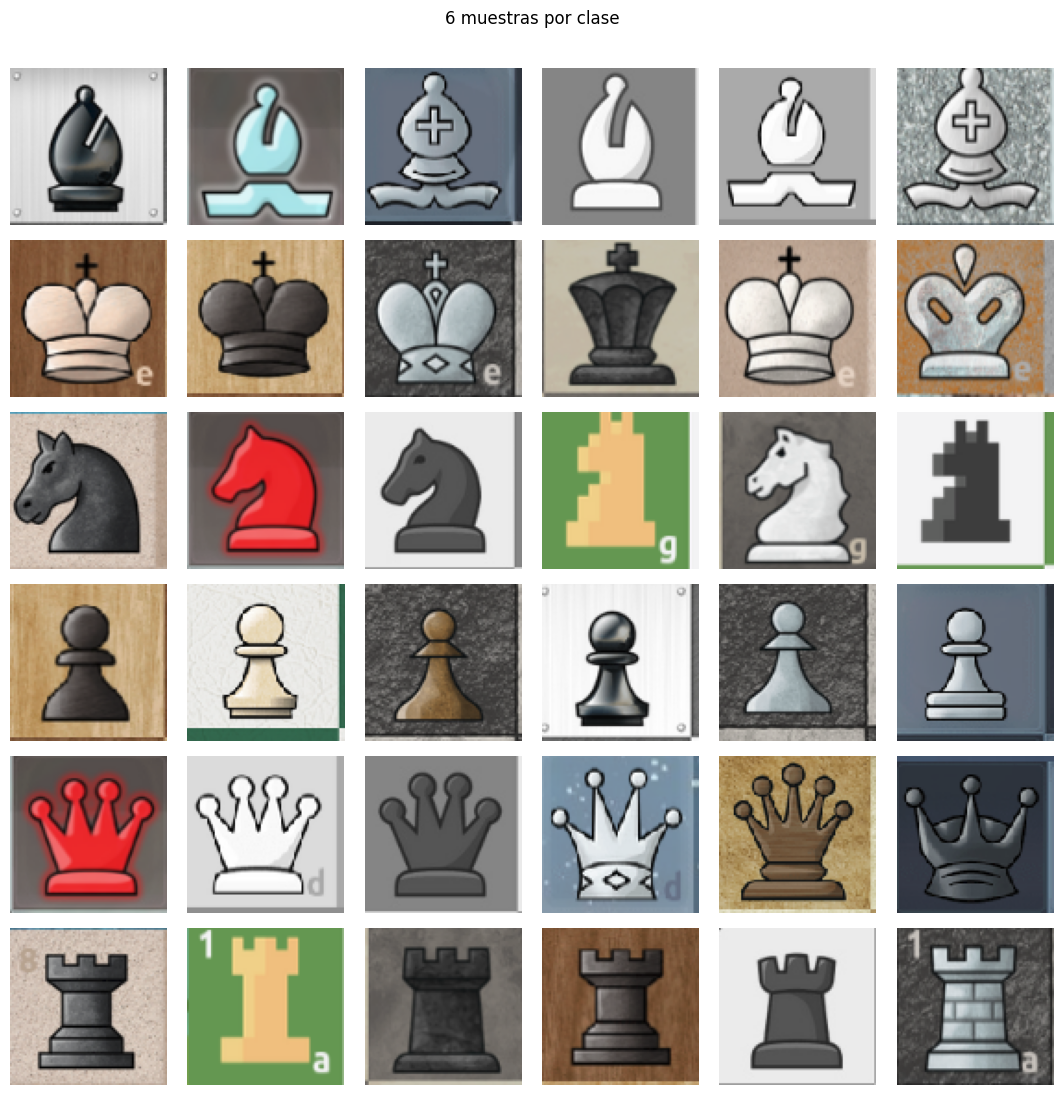

In [4]:
# Mostrar una cuadricula con muestras de cada clase
n_cols = 6
fig, axs = plt.subplots(NUM_CLASSES, n_cols,
                        figsize=(n_cols * 1.8, NUM_CLASSES * 1.8))

for row, cls in enumerate(classes):
    cls_dir   = os.path.join(DATA_DIR, cls)
    img_files = [f for f in os.listdir(cls_dir)
                 if f.lower().endswith((".png",".jpg",".jpeg"))][:n_cols]
    for col, fname in enumerate(img_files):
        img = Image.open(os.path.join(cls_dir, fname)).convert("RGBA")
        # Fondo blanco para iconos con transparencia
        bg  = Image.new("RGBA", img.size, (255, 255, 255, 255))
        bg.paste(img, mask=img.split()[3] if img.mode == "RGBA" else None)
        axs[row, col].imshow(bg.convert("RGB"))
        axs[row, col].axis("off")
        if col == 0:
            axs[row, col].set_ylabel(cls, fontsize=11, rotation=0,
                                    labelpad=46, va="center", fontweight="bold")

plt.suptitle("6 muestras por clase", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


## 4. Configuracion


In [5]:
# ============================================================
# Las imagenes son 85x85. MobileNetV2 acepta cualquier tamano >= 32.
# Usamos 96x96 (multiplo de 32 mas cercano) para aprovechar mejor
# la arquitectura de MobileNetV2 sin perder detalle de los iconos.
IMG_SIZE   = (96, 96)
BATCH_SIZE = 32
EPOCHS_HEAD = 10   # Fase 1: solo cabeza
EPOCHS_FINE = 30   # Fase 2: fine-tuning capas superiores
# ============================================================
print(f"IMG_SIZE: {IMG_SIZE}")


IMG_SIZE: (96, 96)


## 5. Crear Split Train / Validation / Test
El dataset no viene pre-dividido, lo separamos en 70/15/15 por clase.


In [6]:
import shutil, random
from pathlib import Path

SPLIT_ROOT = Path("/content/chess_split")
TRAIN_DIR  = SPLIT_ROOT / "train"
VAL_DIR    = SPLIT_ROOT / "val"
TEST_DIR   = SPLIT_ROOT / "test"

# Recrear carpetas si ya existen (para re-ejecutar sin errores)
if SPLIT_ROOT.exists():
    shutil.rmtree(SPLIT_ROOT)

random.seed(42)

for cls in classes:
    src_dir = Path(DATA_DIR) / cls
    imgs    = sorted([f for f in os.listdir(src_dir)
                      if f.lower().endswith((".png",".jpg",".jpeg"))])
    random.shuffle(imgs)

    n       = len(imgs)
    n_train = int(n * 0.70)
    n_val   = int(n * 0.15)
    # El resto va a test

    splits = {
        TRAIN_DIR: imgs[:n_train],
        VAL_DIR:   imgs[n_train:n_train + n_val],
        TEST_DIR:  imgs[n_train + n_val:],
    }

    for split_dir, split_imgs in splits.items():
        dest = split_dir / cls
        dest.mkdir(parents=True, exist_ok=True)
        for fname in split_imgs:
            shutil.copy(src_dir / fname, dest / fname)

    print(f"{cls}: {n_train} train | {n_val} val | {n - n_train - n_val} test")

print(f"\nSplit completado en: {SPLIT_ROOT}")


bishop: 46 train | 10 val | 11 test
king: 23 train | 5 val | 6 test
knight: 49 train | 10 val | 12 test
pawn: 167 train | 35 val | 37 test
queen: 23 train | 5 val | 6 test
rook: 50 train | 10 val | 12 test

Split completado en: /content/chess_split


## 6. Generadores de Datos


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Para iconos digitales el augmentation es moderado:
# los iconos tienen orientacion fija (la pieza siempre mira al frente)
# pero variar brillo/zoom ayuda con fotos reales de partidas en pantalla
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    horizontal_flip=True,
    rotation_range=10,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    brightness_range=[0.75, 1.25],
    fill_mode="nearest"
)
eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    str(TRAIN_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", seed=42
)
val_gen = eval_datagen.flow_from_directory(
    str(VAL_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)
test_gen = eval_datagen.flow_from_directory(
    str(TEST_DIR), target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode="categorical", shuffle=False
)

NUM_CLASSES   = len(train_gen.class_indices)
class_indices = train_gen.class_indices
idx_to_class  = {v: k for k, v in class_indices.items()}

print(f"Clases ({NUM_CLASSES}): {class_indices}")
print(f"Train: {train_gen.samples} | Val: {val_gen.samples} | Test: {test_gen.samples}")


Found 358 images belonging to 6 classes.
Found 75 images belonging to 6 classes.
Found 84 images belonging to 6 classes.
Clases (6): {'bishop': 0, 'king': 1, 'knight': 2, 'pawn': 3, 'queen': 4, 'rook': 5}
Train: 358 | Val: 75 | Test: 84


## 7. Modelo — MobileNetV2 Fine-Tuning

**Fase 1** (head only, lr=1e-3): la base esta congelada, solo se entrena el clasificador nuevo.  
**Fase 2** (fine-tuning, lr=1e-5): se descongelan las ultimas 30 capas de MobileNetV2.


In [8]:
from tensorflow.keras import models, layers, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2

base_model = MobileNetV2(
    input_shape=(*IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Congelado en Fase 1

network = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(NUM_CLASSES, activation="softmax")
])

network.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
network.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,462 (9.87 MB)

 Trainable params: 329,478 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 8. Fase 1 — Entrenar Solo la Cabeza


In [9]:
cb_early_1 = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=5,
    restore_best_weights=True, verbose=1
)

print("Fase 1: base congelada...")
history_1 = network.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_HEAD, callbacks=[cb_early_1]
)


Fase 1: base congelada...
Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 48s 3s/step - accuracy: 0.6704 - loss: 0.9721 - val_accuracy: 0.9467 - val_loss: 0.2385
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9469 - loss: 0.1900 - val_accuracy: 0.9600 - val_loss: 0.1369
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9777 - loss: 0.0683 - val_accuracy: 0.9467 - val_loss: 0.1212
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9749 - loss: 0.0765 - val_accuracy: 0.9467 - val_loss: 0.1423
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.9693 - loss: 0.0713 - val_accuracy: 0.9733 - val_loss: 0.0551
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9860 - loss: 0.0535 - val_accuracy: 0.9733 - val_loss: 0.0643
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 175ms/step - accuracy: 0.9860 - loss: 0.0510 - val_accuracy: 0.9333 - val_loss: 0.1160
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 133ms/step - accuracy: 0.9888 - loss: 0

## 9. Fase 2 — Fine-Tuning


In [10]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

network.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

cb_early_2 = callbacks.EarlyStopping(
    monitor="val_accuracy", patience=8,
    restore_best_weights=True, verbose=1
)
cb_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=4,
    min_lr=1e-7, verbose=1
)

print("Fase 2: fine-tuning ultimas 30 capas...")
history_2 = network.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS_FINE, callbacks=[cb_early_2, cb_lr]
)


Fase 2: fine-tuning ultimas 30 capas...
Epoch 1/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 35s 2s/step - accuracy: 0.8575 - loss: 0.3629 - val_accuracy: 0.9733 - val_loss: 0.0592 - learning_rate: 1.0000e-05
Epoch 2/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 122ms/step - accuracy: 0.9162 - loss: 0.2476 - val_accuracy: 0.9733 - val_loss: 0.0612 - learning_rate: 1.0000e-05
Epoch 3/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - accuracy: 0.9358 - loss: 0.2301 - val_accuracy: 0.9733 - val_loss: 0.0653 - learning_rate: 1.0000e-05
Epoch 4/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.9413 - loss: 0.2118 - val_accuracy: 0.9733 - val_loss: 0.0671 - learning_rate: 1.0000e-05
Epoch 5/30
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.9504 - loss: 0.1641
Epoch 5: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 117ms/step - accuracy: 0.9525 - loss: 0.1623 - val_accuracy: 0.9733 - val_loss: 0.0694 - learning_rate: 1.0000e-05
Epoch 6/30
12/12 ━━━━━━━━━━━━━━

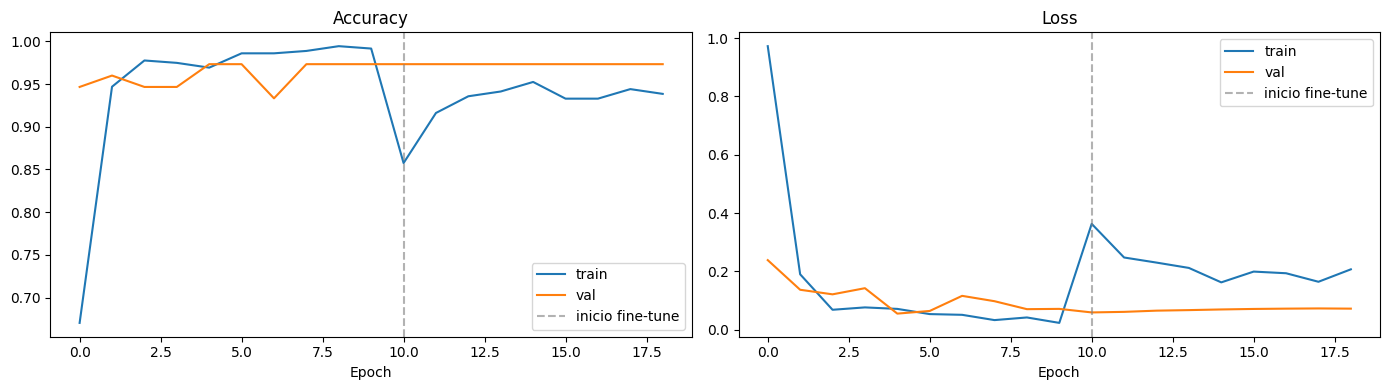

In [11]:
# Historico combinado de ambas fases
acc  = history_1.history["accuracy"]     + history_2.history["accuracy"]
val  = history_1.history["val_accuracy"] + history_2.history["val_accuracy"]
loss = history_1.history["loss"]         + history_2.history["loss"]
vloss= history_1.history["val_loss"]     + history_2.history["val_loss"]
ep1  = len(history_1.history["accuracy"])

fig, axs = plt.subplots(1, 2, figsize=(14, 4))
for ax, tr, vl, title in [(axs[0], acc, val, "Accuracy"),
                           (axs[1], loss, vloss, "Loss")]:
    ax.plot(tr, label="train")
    ax.plot(vl, label="val")
    ax.axvline(ep1, color="gray", linestyle="--", alpha=0.6, label="inicio fine-tune")
    ax.set_title(title); ax.set_xlabel("Epoch"); ax.legend()
plt.tight_layout(); plt.show()


## 10. Evaluacion Final


3/3 ━━━━━━━━━━━━━━━━━━━━ 16s 6s/step
Reporte de clasificacion:
              precision    recall  f1-score   support

      bishop       0.91      0.91      0.91        11
        king       1.00      1.00      1.00         6
      knight       1.00      0.75      0.86        12
        pawn       0.93      1.00      0.96        37
       queen       1.00      1.00      1.00         6
        rook       1.00      1.00      1.00        12

    accuracy                           0.95        84
   macro avg       0.97      0.94      0.95        84
weighted avg       0.96      0.95      0.95        84



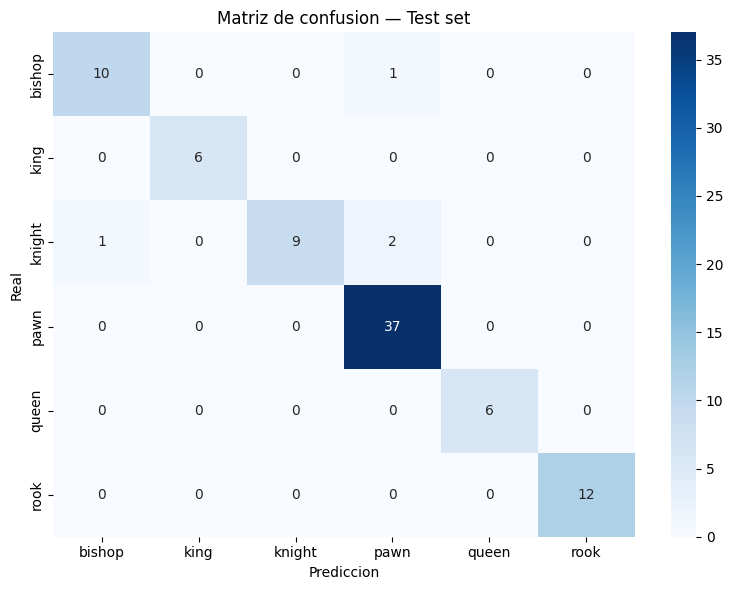

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

pred   = network.predict(test_gen)
y_pred = np.argmax(pred, axis=1)
y_true = test_gen.classes
names  = [idx_to_class[i] for i in range(NUM_CLASSES)]

print("Reporte de clasificacion:")
print(classification_report(y_true, y_pred, target_names=names, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=names, yticklabels=names, cmap="Blues")
plt.title("Matriz de confusion — Test set")
plt.ylabel("Real"); plt.xlabel("Prediccion")
plt.tight_layout(); plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


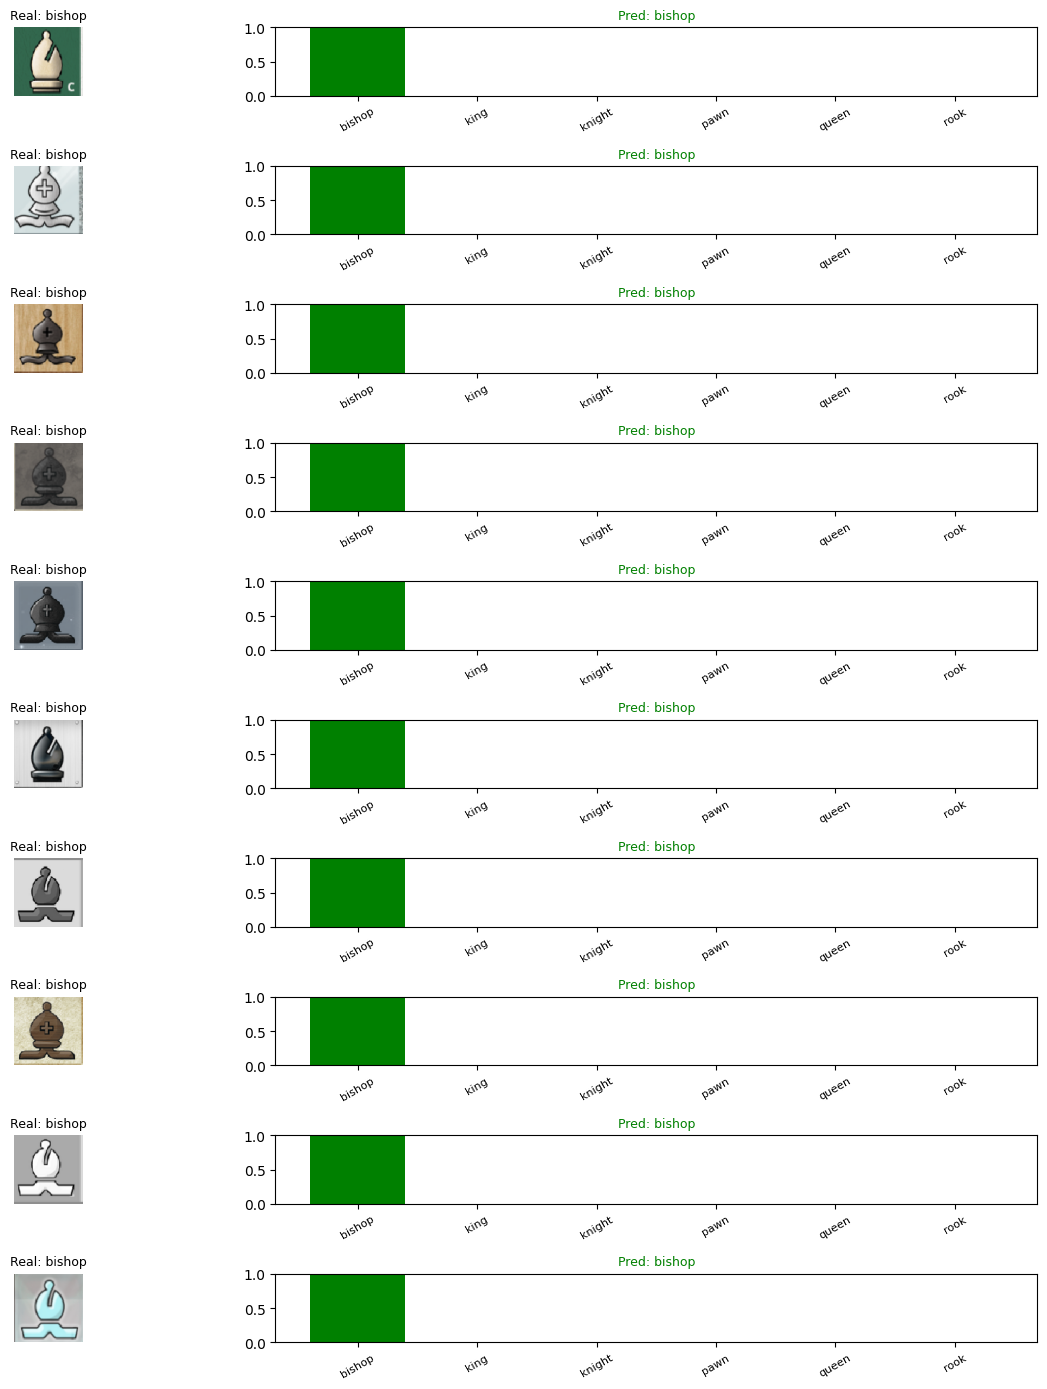

In [13]:
batch_x, batch_y = next(test_gen)
batch_pred = network.predict(batch_x)
n_show = min(10, len(batch_x))

fig = plt.figure(figsize=(14, 14))
for i in range(n_show):
    img_show  = np.clip((batch_x[i] + 1.0) / 2.0, 0, 1)
    real      = idx_to_class[np.argmax(batch_y[i])]
    predicted = idx_to_class[np.argmax(batch_pred[i])]
    color     = "green" if real == predicted else "red"

    fig.add_subplot(n_show, 2, 2*i+1)
    plt.imshow(img_show); plt.title(f"Real: {real}", fontsize=9); plt.axis("off")

    fig.add_subplot(n_show, 2, 2*i+2)
    plt.bar(range(NUM_CLASSES), batch_pred[i], color=color)
    plt.xticks(range(NUM_CLASSES), names, rotation=30, fontsize=8)
    plt.ylim(0, 1)
    plt.title(f"Pred: {predicted}", fontsize=9, color=color)

plt.tight_layout(); plt.show()


## 11. Probar con Imagen Externa


Sube una imagen de una pieza de ajedrez:


Saving roo.png to roo.png
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


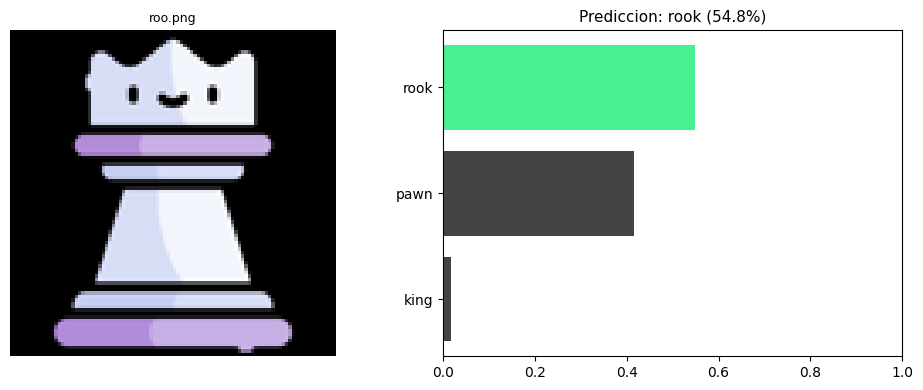

In [17]:
from google.colab import files as colab_files
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import io

print("Sube una imagen de una pieza de ajedrez:")
uploaded = colab_files.upload()

for fname, data in uploaded.items():
    img        = Image.open(io.BytesIO(data)).convert("RGB")
    img_r      = img.resize((IMG_SIZE[1], IMG_SIZE[0]))
    arr        = preprocess_input(np.array(img_r, dtype="float32"))
    pred_ext   = network.predict(np.expand_dims(arr, 0))[0]
    top3       = np.argsort(pred_ext)[::-1][:3]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.imshow(img_r); ax1.axis("off"); ax1.set_title(fname, fontsize=9)
    colors = ["#4af090" if i == 0 else "#444" for i in range(3)]
    ax2.barh([idx_to_class[j] for j in top3[::-1]],
             [pred_ext[j] for j in top3[::-1]], color=colors[::-1])
    ax2.set_xlim(0, 1)
    ax2.set_title(
        f"Prediccion: {idx_to_class[top3[0]]} ({pred_ext[top3[0]]*100:.1f}%)",
        fontsize=11)
    plt.tight_layout(); plt.show()


## 12. Guardado del Modelo


In [15]:
import json

network.save("modelo_iconos_ajedrez.keras")
print("[1/2] modelo_iconos_ajedrez.keras guardado")

labels_out = {str(i): idx_to_class[i] for i in range(NUM_CLASSES)}
labels_out["img_size"]      = list(IMG_SIZE)
labels_out["channels"]      = 3
labels_out["num_classes"]   = NUM_CLASSES
labels_out["preprocessing"] = "mobilenet_v2"
with open("labels.json", "w") as f:
    json.dump(labels_out, f, indent=2, ensure_ascii=False)
print("[2/2] labels.json guardado")
print("Clases:", {k: v for k, v in labels_out.items() if k.isdigit()})


[1/2] modelo_iconos_ajedrez.keras guardado
[2/2] labels.json guardado
Clases: {'0': 'bishop', '1': 'king', '2': 'knight', '3': 'pawn', '4': 'queen', '5': 'rook'}


In [16]:
from google.colab import files
files.download("modelo_iconos_ajedrez.keras")
files.download("labels.json")
print("Listo.")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Listo.
